# Tuning hyperparameters

Set directory

In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data:

In [2]:
from Modules.read_data import read_data
import pandas as pd
from pathlib import Path

(
    DK1_train,
    DK1_test,
    DK2_train,
    DK2_test,
    DK1_train_weather,
    DK1_test_weather,
    DK2_train_weather,
    DK2_test_weather
) = read_data("combined_data_cleaned_v5.csv")
print(f"Features: {DK1_train.columns.tolist()}")

def _load_feature_predictions_for_zone(zone):
    prediction_path = Path(project_root) / "Data" / f"feature_predictions_{zone}_2024-2025.csv"
    if not prediction_path.exists():
        print("No precomputed forecasts found.")
        return None

    predictions = pd.read_csv(prediction_path, decimal=",", sep = ";", parse_dates=["Time"])
    predictions = predictions.loc[:, ~predictions.columns.duplicated()].copy()
    if "DKZone" in predictions.columns:
        predictions = predictions.loc[predictions["DKZone"] == zone].copy()
    return predictions


dk1_feature_predictions = _load_feature_predictions_for_zone("DK1")
dk2_feature_predictions = _load_feature_predictions_for_zone("DK2")
if (dk1_feature_predictions is not None) and (dk2_feature_predictions is not None):
    print("\nPrecomputed forecasts loaded.")

dk1_use_precomputed_feature_values = dk1_feature_predictions is not None
dk2_use_precomputed_feature_values = dk2_feature_predictions is not None

Notebook_dir: c:\Users\chris\Documents\Python\Speciale_Kode\Modules
Python_dir: c:\Users\chris\Documents\Python\Speciale_Kode
Data_folder: c:\Users\chris\Documents\Python\Speciale_Kode\Data
Training data shape (DK1): (78888, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78888, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%
Features: ['DKPrice', 'Time', 'OffshoreWindPower', 'OnshoreWindPower', 'HydroPower', 'SolarPower', 'Biomass', 'Biogas', 'Waste', 'FossilGas', 'FossilOil', 'FossilHardCoal', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeSweden', 'ExchangeNorway', 'ExchangeNetherlands', 'WindSpeed', 'Radiation', 'DEPrice', 'NO2Price', 'SE3Price', 'SE4Price', 'NLPrice', 'GrossCon', 'TotalProduction', 'Year', 'Month', 'Day', 'WeekDay', 'Hour', 'OffshoreWindCapacity', 'OnshoreWindCapacity', 'SolarPowerCapacity', 'GrossCon_lag1', 'GrossCon_lag24', 'Price_lag1', 'Price_lag24']

Precomputed forecasts loaded.


## Choose validation setup


**Setup 1**

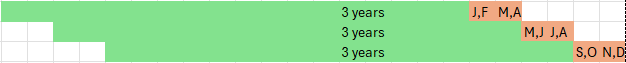

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

In [3]:
setup = 2

Import models

In [4]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from Modules.Load_RF_forecast_models import load_rf_models

rf_models = None
if not (dk1_use_precomputed_feature_values and dk2_use_precomputed_feature_values):
    # load_rf_models currently supports only the optional timeout argument.
    rf_models = load_rf_models(user="Christine - laptop")      # set user to "Nikolaj" or "Christine"

rf_models = load_rf_models(user="Christine - desktop")


wandb: Downloading large artifact 'rf_OffshoreWindPower_DK1:latest', 1817.80MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (4317.8MB/s)
c:\Users\chris\anaconda3\envs\ds809\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\anaconda3\envs\ds809\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✓ Loaded RF model for OffshoreWindPower_DK1 from C:\Users\chris\Documents\Python\Personlig\Artifacts\OffshoreWindPower_DK1


wandb: Downloading large artifact 'rf_OffshoreWindPower_DK2:latest', 1809.79MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5276.4MB/s)


✓ Loaded RF model for OffshoreWindPower_DK2 from C:\Users\chris\Documents\Python\Personlig\Artifacts\OffshoreWindPower_DK2


wandb: Downloading large artifact 'rf_OnshoreWindPower_DK1:latest', 1817.91MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5542.4MB/s)


✓ Loaded RF model for OnshoreWindPower_DK1 from C:\Users\chris\Documents\Python\Personlig\Artifacts\OnshoreWindPower_DK1


wandb: Downloading large artifact 'rf_OnshoreWindPower_DK2:latest', 1815.11MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:01.2 (1508.8MB/s)


✓ Loaded RF model for OnshoreWindPower_DK2 from C:\Users\chris\Documents\Python\Personlig\Artifacts\OnshoreWindPower_DK2


wandb: Downloading large artifact 'rf_SolarPower_DK1:latest', 1666.36MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5323.8MB/s)


✓ Loaded RF model for SolarPower_DK1 from C:\Users\chris\Documents\Python\Personlig\Artifacts\SolarPower_DK1


wandb: Downloading large artifact 'rf_SolarPower_DK2:latest', 1580.46MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (3892.8MB/s)


✓ Loaded RF model for SolarPower_DK2 from C:\Users\chris\Documents\Python\Personlig\Artifacts\SolarPower_DK2


wandb: Downloading large artifact 'rf_TotalProduction_DK1:latest', 1817.61MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (4476.9MB/s)


✓ Loaded RF model for TotalProduction_DK1 from C:\Users\chris\Documents\Python\Personlig\Artifacts\TotalProduction_DK1


wandb: Downloading large artifact 'rf_TotalProduction_DK2:latest', 1817.23MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.5 (3634.5MB/s)


✓ Loaded RF model for TotalProduction_DK2 from C:\Users\chris\Documents\Python\Personlig\Artifacts\TotalProduction_DK2

✓ Successfully loaded 8 RF models


In [5]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

Make train and test periods

In [6]:
import pandas as pd
from Modules.Validation2_noise import _build_validation_folds

price_zone = "DK1"
if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

folds = _build_validation_folds(
    data=dataset,
    train_window=2*8760+8784,        
    val_window=len(test_data),
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data),         # 168 hours = 1 week
    stride=len(test_data),               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=len(test_data) - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Number of folds: {num_folds}")
print(f"Test window start: {val_start} - test window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} test start: {folds[fold]['val_start']} - test end: {folds[fold]['val_end']}")

c:\Users\chris\anaconda3\envs\ds809\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fold 1 train start: 2022-01-01 00:00:00 - train end: 2024-12-31 23:00:00
Number of folds: 1
Test window start: 2025-01-01 00:00:00 - test window end: 2025-12-31 23:00:00
Prediction period: 365 days 00:00:00
Fold 1 test start: 2025-01-01 00:00:00 - test end: 2025-12-31 23:00:00


# Train and test the final model

## Random Forest

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 40.64s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 297.647

Average MAE across all weeks in all folds: 226.233

Average SMAPE across all weeks in all folds: 53.816


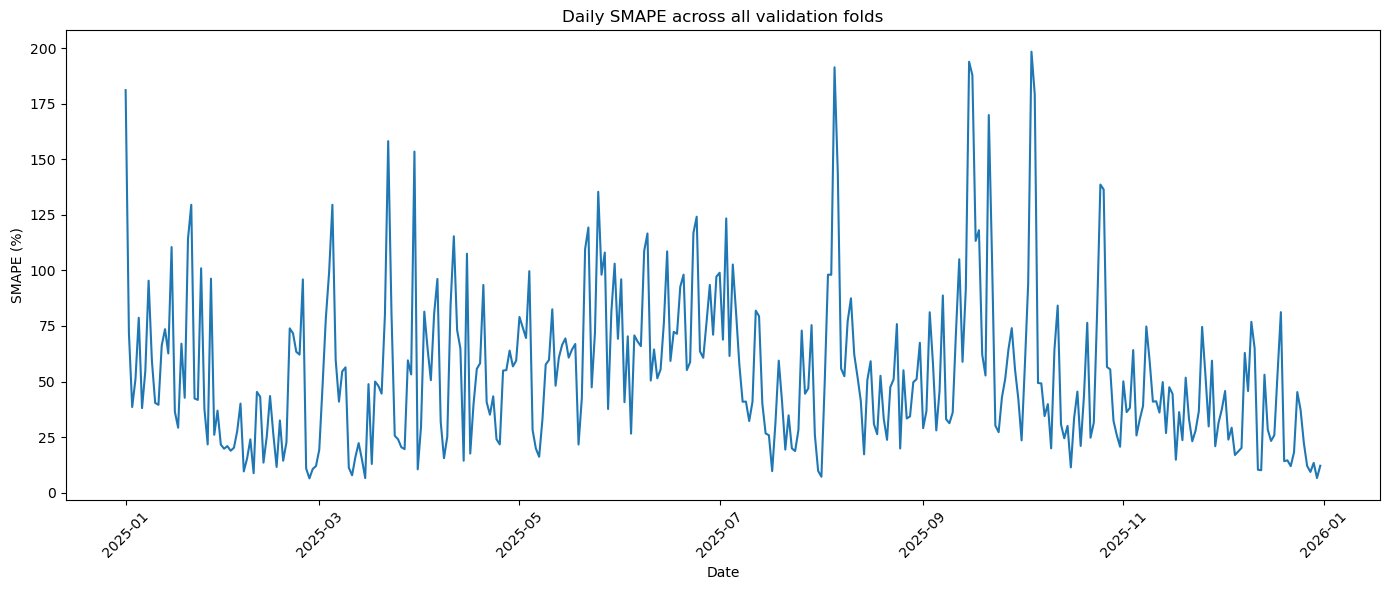

In [7]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from sklearn.ensemble import RandomForestRegressor

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'n_estimators': 200,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_RF_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_RF_predictions2.csv"),
    index=False,
    decimal=","
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 7.24s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 296.380

Average MAE across all weeks in all folds: 224.525

Average SMAPE across all weeks in all folds: 51.338


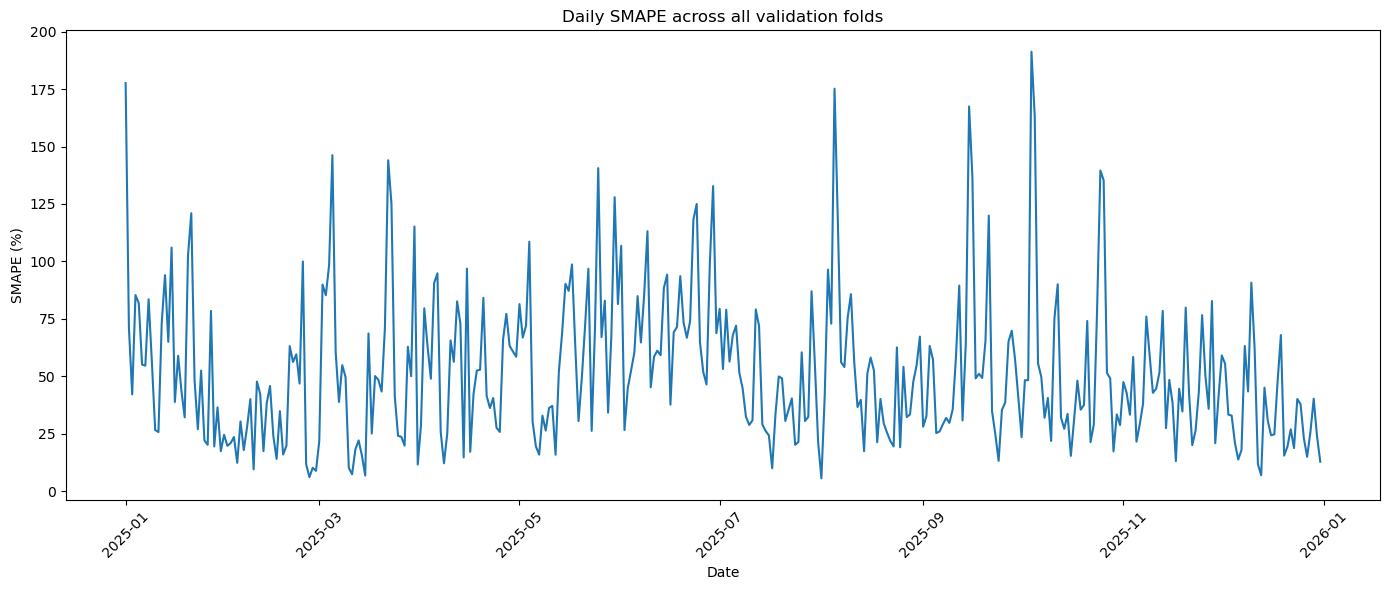

In [8]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from sklearn.ensemble import RandomForestRegressor

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'n_estimators': 50,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 10
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_RF_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_RF_predictions.csv"),
    index=False,
    decimal=","
)

## LightGBM

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7294
[LightGBM] [Info] Number of data points in the train set: 26304, number of used features: 36
[LightGBM] [Info] Start training from score 934.022263
Model trained in 0.46s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 314.543

Average MAE across all weeks in all folds: 237.963

Average SMAPE across all weeks in all folds: 50.990


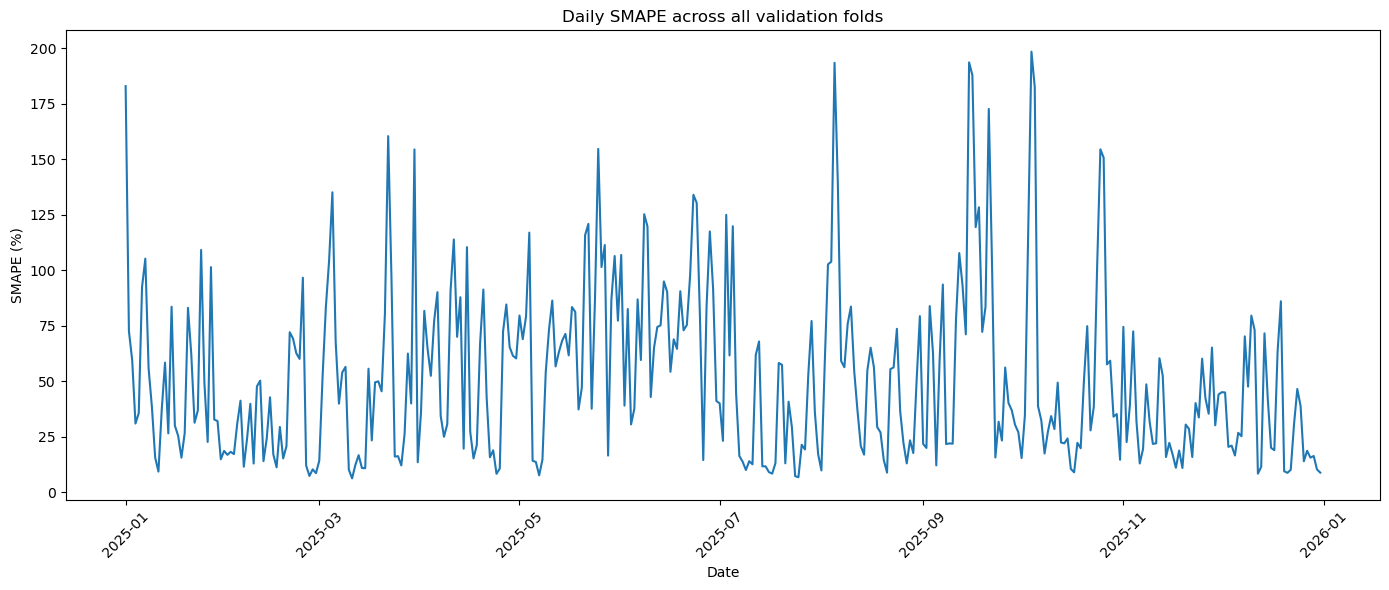

In [9]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from lightgbm import LGBMRegressor

# Initialize model:
model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "n_estimators": 200,
    "learning_rate": 0.01,
    "num_leaves": 15,            
    "max_depth": -1,
    "min_child_samples": 1,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

numeric_cols = feature_predictions.columns.difference(["Time", "DKZone"])
feature_predictions[numeric_cols] = feature_predictions[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce")
)

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_LightGBM_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_LightGBM_predictions.csv"),
    index=False,
    decimal=","
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6509
[LightGBM] [Info] Number of data points in the train set: 26304, number of used features: 33
[LightGBM] [Info] Start training from score 898.735589
Model trained in 1.13s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 295.866

Average MAE across all weeks in all folds: 226.969

Average SMAPE across all weeks in all folds: 49.775


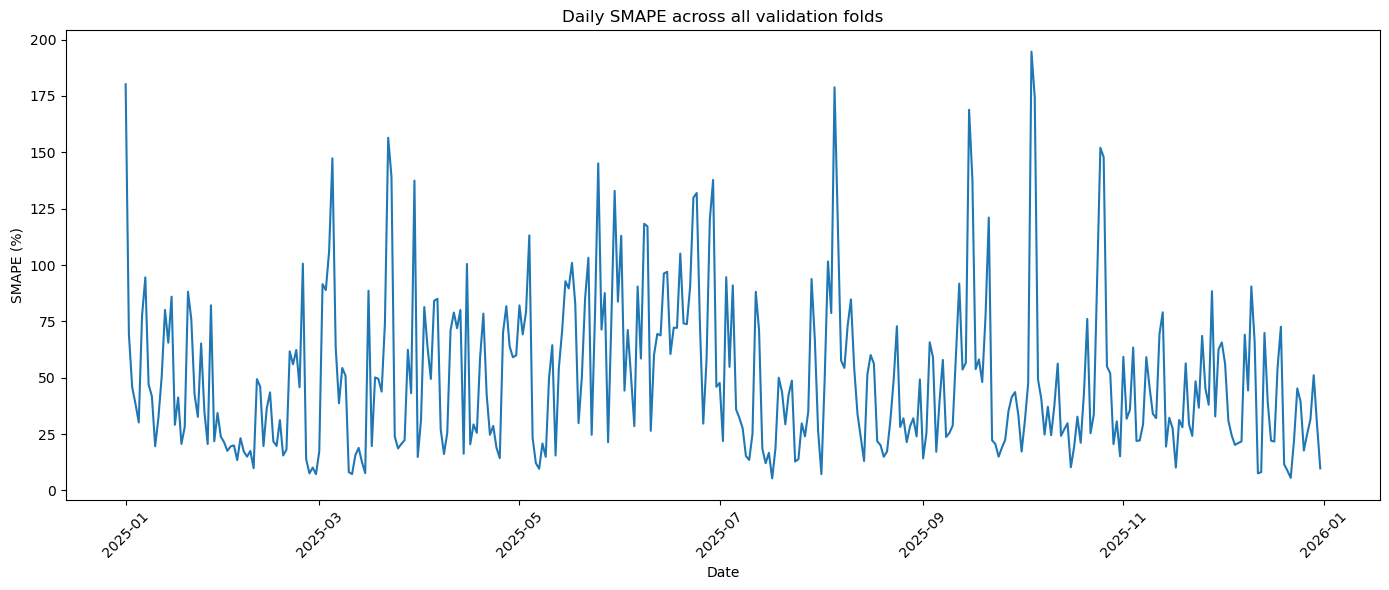

In [10]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from lightgbm import LGBMRegressor

# Initialize model:
model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "n_estimators": 200,
    "learning_rate": 0.01,
    "num_leaves": 127,            
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)

numeric_cols = feature_predictions.columns.difference(["Time", "DKZone"])
feature_predictions[numeric_cols] = feature_predictions[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "."), errors="coerce")
)

results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_LightGBM_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = f"{base_filename}_{counter}.csv"
    filename = os.path.join(folder, filename)
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_LightGBM_predictions.csv"),
    index=False,
    decimal=","
)

## Linear Regression

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36


c:\Users\chris\anaconda3\envs\ds809\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.203e+07, tolerance: 1.905e+06
  model = cd_fast.enet_coordinate_descent(


Model trained in 2.62s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 454.609

Average MAE across all weeks in all folds: 384.038

Average SMAPE across all weeks in all folds: 95.486


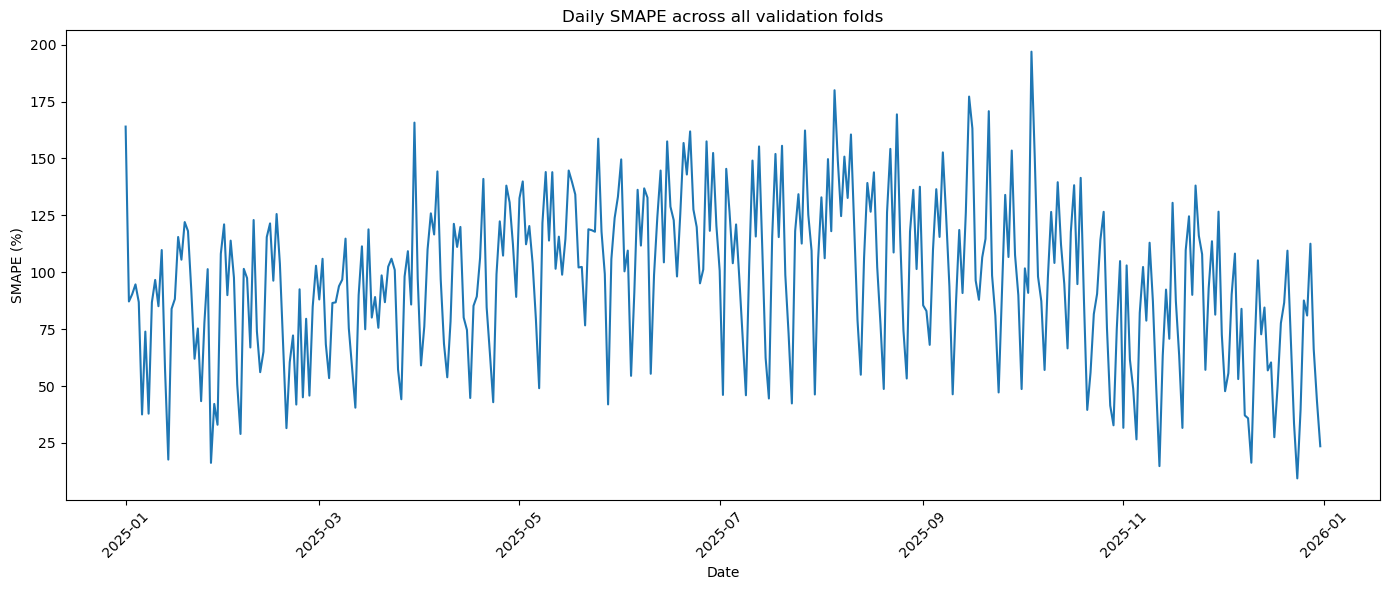

In [11]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Initialize model:
model = Lasso(max_iter=5000)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'alpha': 0.0001
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_Lasso_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_Lasso_predictions.csv"),
    index=False,
    decimal=","
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 0.06s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 437.196

Average MAE across all weeks in all folds: 365.079

Average SMAPE across all weeks in all folds: 84.214


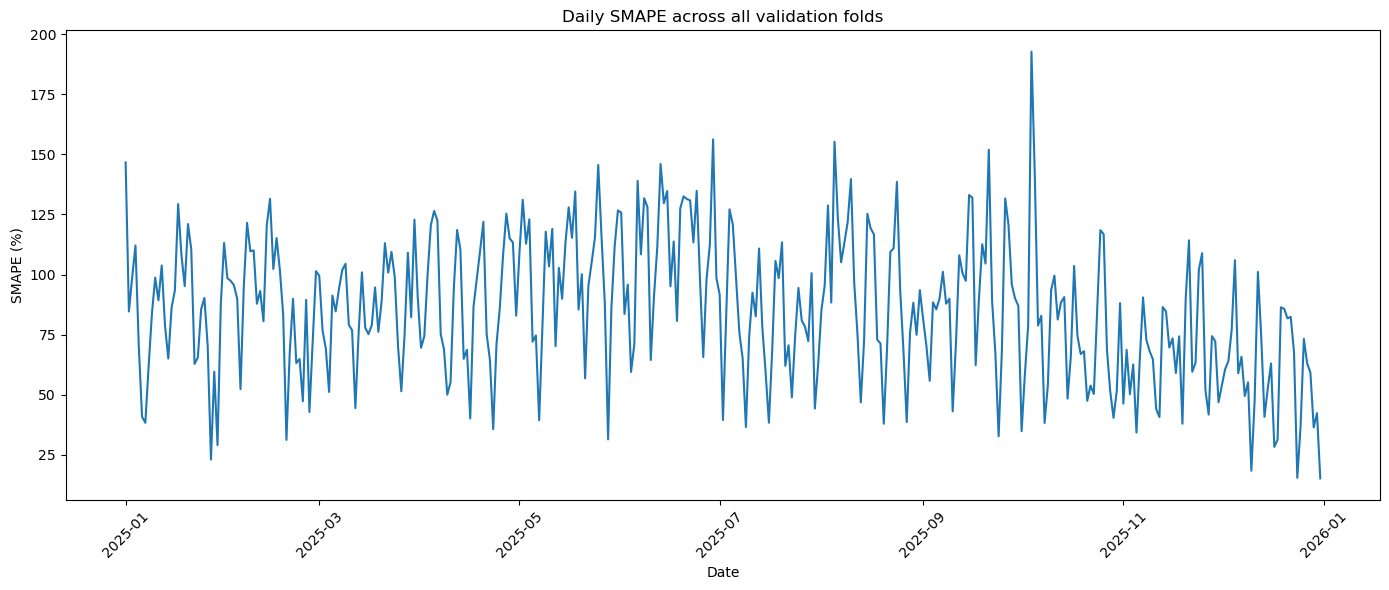

In [12]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Initialize model:
model = Lasso(max_iter=5000)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'alpha': 50
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_Lasso_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_Lasso_predictions.csv"),
    index=False,
    decimal=","
)

## Support Vector Regression

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from sklearn.svm import SVR

# Initialize model:
model = SVR()

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "kernel": "poly",
    "C": 0.1,
    "gamma": "auto",
    "epsilon": 0.1,
    "degree": 2,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_SVR_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_SVR_predictions.csv"),
    index=False,
    decimal=","
)

Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36


Training fold details: train_start=2022-01-01 00:00:00, train_end=2024-12-31 23:00:00, hours=26304, rows=26304, features=36
Model trained in 55.62s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 373.687

Average MAE across all weeks in all folds: 282.031

Average SMAPE across all weeks in all folds: 53.073


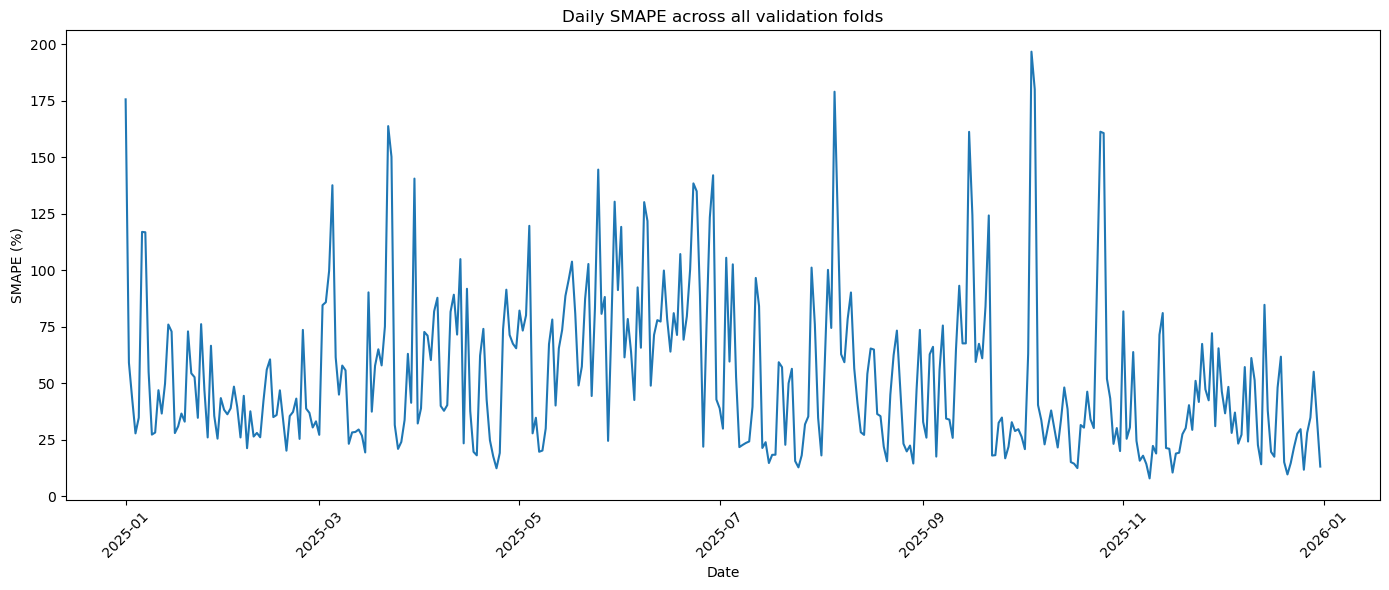

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from sklearn.svm import SVR

# Initialize model:
model = SVR()

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "kernel": "rbf",
    "C": 1.0,
    "gamma": "auto",
    "epsilon": 0.5,
}
# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_SVR_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_SVR_predictions.csv"),
    index=False,
    decimal=","
)

## XGBoost

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from xgboost import XGBRegressor

# Initialize model:
model = XGBRegressor()

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 5,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_XGBoost_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_XGBoost_predictions.csv"),
    index=False,
    decimal=","
)

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2_noise import run_cross_validation
import os
from xgboost import XGBRegressor

# Initialize model:
model = XGBRegressor()

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 7,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 0.7,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
folder = os.path.join(folder, "With_noise")
base_filename = f"{price_zone}_XGBoost_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_XGBoost_predictions.csv"),
    index=False,
    decimal=","
)